<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Feature%20Selection%20and%20Engineering/Feature_Engineering1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

def create_dataset(num_samples=200):
    X1 = []
    X2 = []
    Y = []

    # Target counts for balanced dataset
    target_0_count = num_samples // 2
    target_1_count = num_samples // 2

    current_target_0 = 0
    current_target_1 = 0

    # Generate samples for Y=0 (inside the circle)
    while current_target_0 < target_0_count:
        x1_val = np.random.uniform(-4, 4)  # Reasonable range for X1
        x2_val = np.random.uniform(-4, 4)  # Reasonable range for X2
        if x1_val**2 + x2_val**2 <= 10:
            X1.append(x1_val)
            X2.append(x2_val)
            Y.append(0)
            current_target_0 += 1

    # Generate samples for Y=1 (outside the circle)
    while current_target_1 < target_1_count:
        x1_val = np.random.uniform(-5, 5) # Larger range to find points outside more easily
        x2_val = np.random.uniform(-5, 5) # Larger range
        if x1_val**2 + x2_val**2 > 10:
            X1.append(x1_val)
            X2.append(x2_val)
            Y.append(1)
            current_target_1 += 1

    df = pd.DataFrame({'X1': X1, 'X2': X2, 'Y': Y})
    return df

# Create the dataset
dataset = create_dataset()
display(dataset.head())
print(f"Dataset shape: {dataset.shape}")
print(f"Value counts for Y:\n{dataset['Y'].value_counts()}")

,X1,X2,Y
0,1.564080,0.050154,0
1,-2.829109,0.325414,0
2,-2.680326,-0.937724,0
3,2.642961,0.415986,0
4,-0.534760,0.111705,0


Dataset shape: (200, 3)
Value counts for Y:
Y
0    100
1    100
Name: count, dtype: int64


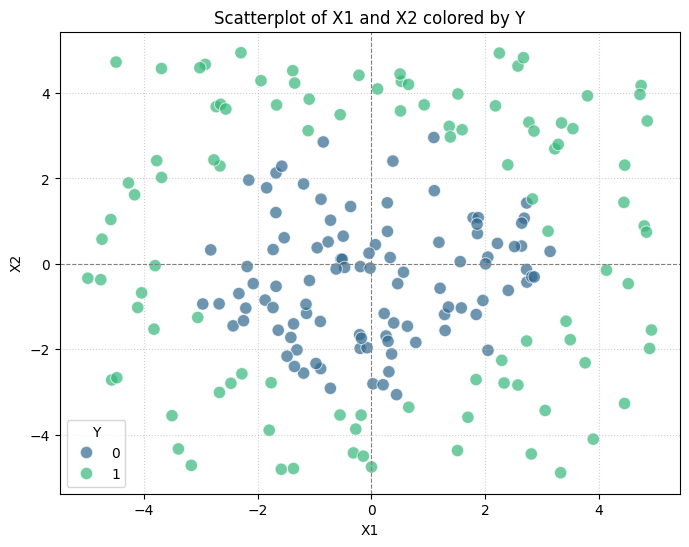

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='X1', y='X2', hue='Y', data=dataset, palette='viridis', s=80, alpha=0.7)
plt.title('Scatterplot of X1 and X2 colored by Y')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare the data
X = dataset[['X1', 'X2']]
y = dataset['Y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (140, 2), (140,)
Testing set shape: (60, 2), (60,)


In [4]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [5]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)


Accuracy: 0.6667

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67        30
           1       0.67      0.67      0.67        30

    accuracy                           0.67        60
   macro avg       0.67      0.67      0.67        60
weighted avg       0.67      0.67      0.67        60


Confusion Matrix:
 [[20 10]
 [10 20]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


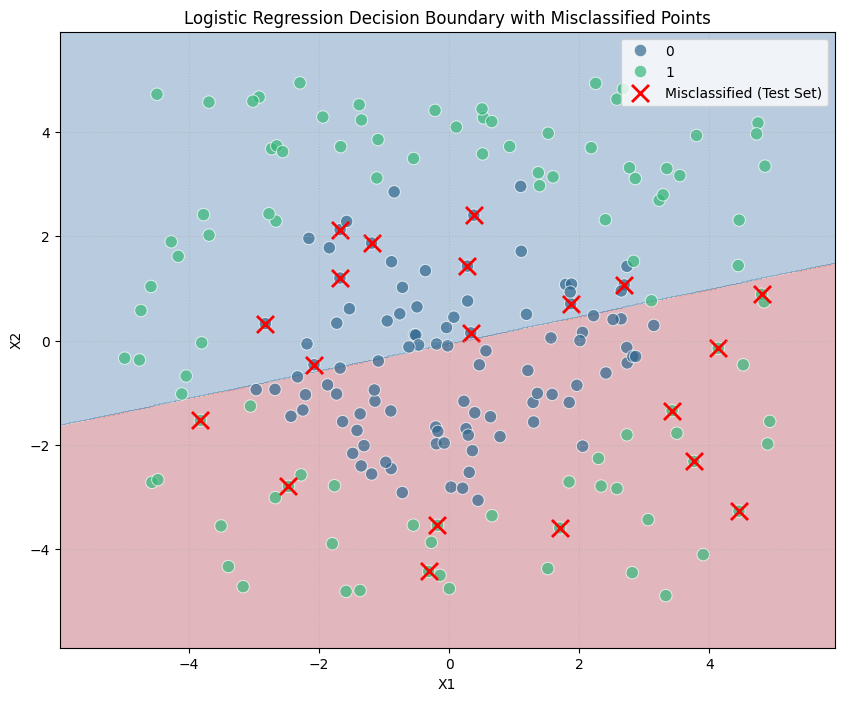

In [6]:
plt.figure(figsize=(10, 8))

# Plot the decision boundary
x_min, x_max = X['X1'].min() - 1, X['X1'].max() + 1
y_min, y_max = X['X2'].min() - 1, X['X2'].max() + 1
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.3)

# Plot the training points
sns.scatterplot(x='X1', y='X2', hue='Y', data=dataset, palette='viridis', s=80, alpha=0.7)

# Highlight misclassified points from the test set
misclassified_indices = np.where(y_pred != y_test)[0]
misclassified_X1 = X_test.iloc[misclassified_indices]['X1']
misclassified_X2 = X_test.iloc[misclassified_indices]['X2']

plt.scatter(misclassified_X1, misclassified_X2, marker='x', s=150, color='red', label='Misclassified (Test Set)', linewidth=2)

plt.title('Logistic Regression Decision Boundary with Misclassified Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [7]:
# Create a new DataFrame with X1, X2, Y, and the computed feature X3
new_dataset = dataset.copy()
new_dataset['X3'] = new_dataset['X1']**2 + new_dataset['X2']**2

display(new_dataset.head())
print(f"New dataset shape: {new_dataset.shape}")

,X1,X2,Y,X3
0,1.564080,0.050154,0,2.448861
1,-2.829109,0.325414,0,8.109753
2,-2.680326,-0.937724,0,8.063474
3,2.642961,0.415986,0,7.158287
4,-0.534760,0.111705,0,0.298446


New dataset shape: (200, 4)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare the data with the new feature X3
X_new = new_dataset[['X1', 'X2', 'X3']]
y_new = new_dataset['Y']

# Split the data into training and testing sets (using the same parameters as before)
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.3, random_state=42, stratify=y_new)

print(f"New Training set shape: {X_new_train.shape}, {y_new_train.shape}")
print(f"New Testing set shape: {X_new_test.shape}, {y_new_test.shape}")

New Training set shape: (140, 3), (140,)
New Testing set shape: (60, 3), (60,)


In [9]:
# Initialize and train a new Logistic Regression model with X3
model_with_X3 = LogisticRegression(random_state=42)
model_with_X3.fit(X_new_train, y_new_train)

print("Logistic Regression model with X3 trained successfully.")

Logistic Regression model with X3 trained successfully.


In [10]:
# Make predictions on the test set with the new model
y_new_pred = model_with_X3.predict(X_new_test)

# Evaluate the new model
accuracy_new = accuracy_score(y_new_test, y_new_pred)
report_new = classification_report(y_new_test, y_new_pred)
conf_matrix_new = confusion_matrix(y_new_test, y_new_pred)

print(f"\nAccuracy with X3: {accuracy_new:.4f}")
print("\nClassification Report with X3:\n", report_new)
print("\nConfusion Matrix with X3:\n", conf_matrix_new)

if accuracy_new > accuracy: # 'accuracy' from the previous model without X3
    print("\nAdding X3 improved the model's accuracy!")
elif accuracy_new < accuracy:
    print("\nAdding X3 slightly decreased the model's accuracy.")
else:
    print("\nAdding X3 resulted in the same accuracy.")


Accuracy with X3: 0.9833

Classification Report with X3:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.97      1.00      0.98        30

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix with X3:
 [[29  1]
 [ 0 30]]

Adding X3 improved the model's accuracy!


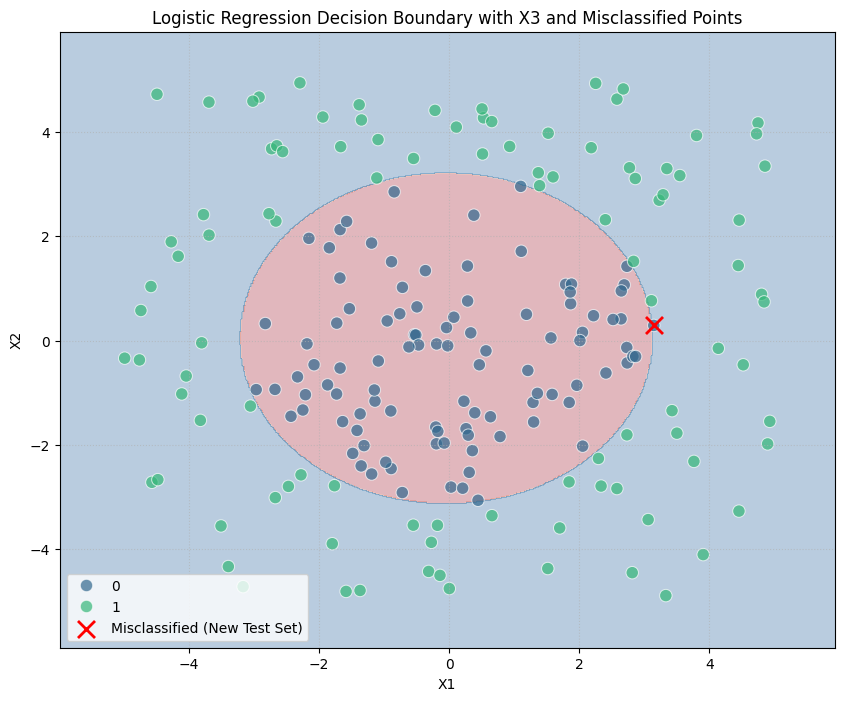

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Define the grid for plotting the decision boundary
x_min, x_max = new_dataset['X1'].min() - 1, new_dataset['X1'].max() + 1
y_min, y_max = new_dataset['X2'].min() - 1, new_dataset['X2'].max() + 1
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Create a DataFrame for prediction, including the X3 feature
grid_data = pd.DataFrame({
    'X1': xx.ravel(),
    'X2': yy.ravel(),
    'X3': xx.ravel()**2 + yy.ravel()**2  # Compute X3 for the grid
})

# Predict on the grid using the model with X3
Z_new = model_with_X3.predict(grid_data[['X1', 'X2', 'X3']])
Z_new = Z_new.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z_new, cmap=plt.cm.RdBu, alpha=0.3)

# Plot the training points (from the original dataset for context)
sns.scatterplot(x='X1', y='X2', hue='Y', data=new_dataset, palette='viridis', s=80, alpha=0.7)

# Highlight misclassified points from the test set of the new model
misclassified_indices_new = np.where(y_new_pred != y_new_test)[0]
misclassified_X1_new = X_new_test.iloc[misclassified_indices_new]['X1']
misclassified_X2_new = X_new_test.iloc[misclassified_indices_new]['X2']

plt.scatter(misclassified_X1_new, misclassified_X2_new, marker='x', s=150, color='red', label='Misclassified (New Test Set)', linewidth=2)

plt.title('Logistic Regression Decision Boundary with X3 and Misclassified Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

The logistic regression model has been applied and evaluated. The accuracy, classification report, and confusion matrix provide insight into its performance.

In [12]:
print("Coefficients for the original model (without X3):")
print(f"X1 coefficient: {model.coef_[0][0]:.4f}")
print(f"X2 coefficient: {model.coef_[0][1]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

print("\nCoefficients for the new model (with X3):")
print(f"X1 coefficient: {model_with_X3.coef_[0][0]:.4f}")
print(f"X2 coefficient: {model_with_X3.coef_[0][1]:.4f}")
print(f"X3 coefficient: {model_with_X3.coef_[0][2]:.4f}")
print(f"Intercept: {model_with_X3.intercept_[0]:.4f}")

Coefficients for the original model (without X3):
X1 coefficient: -0.0207
X2 coefficient: 0.0792
Intercept: 0.0055

Coefficients for the new model (with X3):
X1 coefficient: 0.1771
X2 coefficient: -0.1583
X3 coefficient: 1.9579
Intercept: -19.6606
